In [1]:
#Imorting Libraries
import pandas as pd
from datasets import load_dataset
from datetime import datetime
import ast
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [2]:
#Data loading
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [3]:
#Data CleanUp
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

<Axes: xlabel='count', ylabel='job_location'>

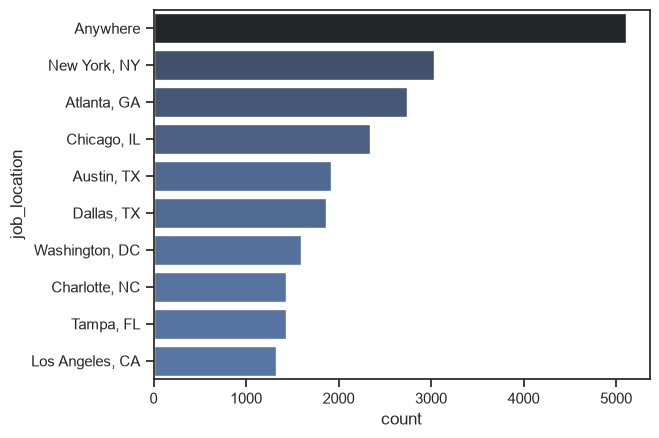

In [4]:
# Set the overall visual style to 'ticks' (adds small axis marks, removes background grid)
sns.set_theme(style="ticks")

# Filter for US Data Analyst jobs only and create a clean, independent copy of the data
df_us_da = df[
    (df["job_title_short"] == "Data Analyst")
    & (df["job_country"] == "United States")
].copy()

# Count jobs per location, take the top 10, and convert it to a new DataFrame
counts_by_location = (
    df_us_da["job_location"].value_counts().head(10).to_frame().copy()
)

# Create a horizontal bar plot with a dark-to-blue gradient palette (dark:b_r)
sns.barplot(
    counts_by_location,
    x="count",
    y="job_location",
    hue="count",
    palette="dark:b_r",
    legend=False,
)


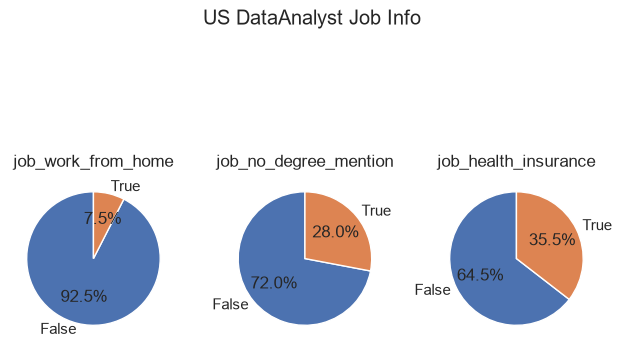

In [5]:
import matplotlib.pyplot as plt

# Create 1 row with 3 side-by-side empty subplots
fig, ax = plt.subplots(1, 3)

# List the specific columns to analyze and plot
to_plot_list = [
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
]

# Loop through columns; 'i' tracks the subplot index, 'to_plot' is the column name
for i, to_plot in enumerate(to_plot_list):
    # Count value frequencies and plot as a pie chart in the current subplot slot (ax[i])
    df_us_da[to_plot].value_counts().plot(
        kind="pie",
        startangle=90,
        autopct="%1.1f%%",
        title=to_plot,
        ax=ax[i],  # 90° rotates start to top; autopct formats percentage text
    )

# Add a single main title above all three pie charts
fig.suptitle("US DataAnalyst Job Info")

# Automatically fix spacing so titles and charts don't overlap
fig.tight_layout()


Text(0.5, 1.0, 'US Top 10 Data Analyst Companies Job Post Counts')

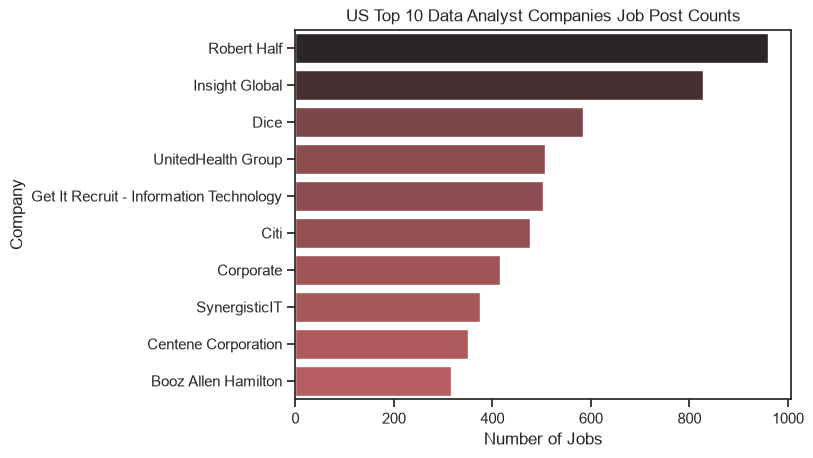

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count job posts per company, take the top 10, and convert it to a new DataFrame
company_counts = df_us_da["company_name"].value_counts().head(10).to_frame().copy()

# Create horizontal bar plot (x='count', y='company_name') with a dark-to-red gradient palette
sns.barplot(
    company_counts,
    x="count",
    y="company_name",
    hue="count",
    palette="dark:r_r",
    legend=False,
)

# Label the horizontal X-axis
plt.xlabel("Number of Jobs")

# Label the vertical Y-axis
plt.ylabel("Company")

# Add the main title at the top of the chart
plt.title("US Top 10 Data Analyst Companies Job Post Counts")
